# 심층 신경망

1. 심층 신경망 (Deep Neural Network, DNN)

    - 입력층과 출력층 사이에 여러 개의 은닉층(hidden layer) 을 가진 인공 신경망입니다.
    
    - 은닉층이 2개 이상 존재하는 신경망을 일반적으로 "심층(Deep) 신경망" 이라고 부릅니다.

2. 신경망의 기본 구조
    
    - 입력층(Input Layer) : 데이터가 처음 들어오는 곳입니다.

    - 은닉층(Hidden Layer) : 입력층과 출력층 사이에 존재하는 모든 층을 의미하며, 입력 데이터를 여러 단계로 변환하면서 데이터의 중요한 패턴(특성)을 학습합니다.

    - 출력층(Output Layer) : 최종 예측값을 내놓는 마지막 층입니다.

In [1]:
import tensorflow as tf

# TensorFlow / Numpy / Python 에서 사용하는
# 난수 생성 시드(seed)를 42로 고정합니다.
# 같은 시드를 사용하면 난수 생성의 시작 상태가 동일해집니다.
tf.keras.utils.set_random_seed(42)

# GPU는 병렬 연산을 수행하기 때문에
# 연산 순서가 실행 시점마다 달라질 수 있습니다.
# 이로 인해 같은 코드라도 결과가 미세하게 달라지는
# 비결정적(non-deterministic) 연산이 발생할 수 있습니다.
# 따라서 시드를 고정하더라도 100% 동일한 결과가
# 항상 보장되지는 않습니다.

# TensorFlow 연산에서 발생하는 비결정성을 최소화하기 위해
# 가능한 한 연산 순서와 알고리즘을 고정하도록 설정합니다.
tf.config.experimental.enable_op_determinism()

---
데이터 가져오기

In [2]:
import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [3]:
from sklearn.model_selection import train_test_split

train_scaled = train_input / 255.0     # 0 ~ 255 범위 -> 0 ~ 1 로 변환

# (60000, 28, 28) => 60,000개의 28 x 28 이미지
# => (60000, 28 * 28) 로 변환
train_scaled = train_scaled.reshape(-1, 28 * 28)

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

---
### 활성화 함수 (Activation Function)

- 층에서 계산된 선형 방정식 값($z$)을 비선형적인 신호로 변환하여 다음 층으로 전달하는 역할을 합니다.

1. 은닉층의 활성화 함수
    - 출력층에 비해 비교적 자유롭게 선택할 수 있으며, 대표적으로 다음과 같은 함수들을 사용합니다.
    - 시그모이드(Sigmoid)함수 : 전통적인 함수로, 출력값을 0 ~ 1 사이로 압축합니다.
    - 렐루(ReLU) 함수 : 현대 신경망에서 가장 선호되는 함수입니다. 0보다 큰 값을 그대로, 0보다 작은 값은 0으로 처리하여 연산 속도가 빠릅니다.

2. 출력층의 활성화 함수
    - 출력층에 적용하는 활성화 함수는 해결하려는 문제의 종류에 따라 제한적으로 사용됩니다.
    - 이진 분류 : 시그모이드(Sigmoid) 함수를 사용합니다.
    - 다중 분류 : 소프트맥스(SoftMax) 함수를 사용합니다.

---
### 사이킷런 vs 케라스 용어

의미 | 사이킷런(scikit-learn) 용어 | 케라스(Keras) 용어
--- | --- | ---
손실 함수 | loss | loss ( model.compile( ) 내에서 설정 )
반복 횟수 | max_iter | epochs
평가 메서드 | score( ) | evaluate( )

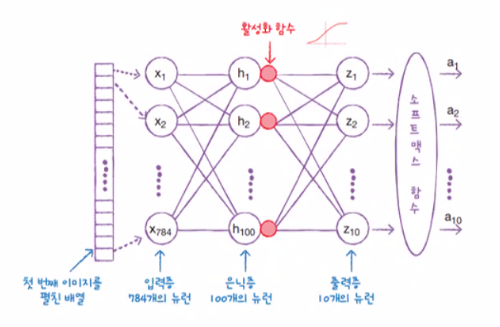

In [4]:
inputs = keras.Input(shape=(784,))                      # 입력층
dense1 = keras.layers.Dense(100, activation='sigmoid')  # 은닉층 (뉴런 개수는 특별한 기준이 없으나 출력층의 뉴런보다는 많게 만듭니다.)
dense2 = keras.layers.Dense(10, activation='softmax')   # 출력층

---
### 심층 신경망(deep neural network, DNN) 만들기

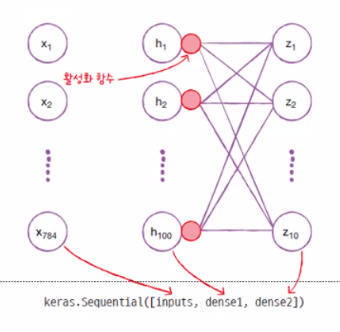

In [5]:
model = keras.Sequential([inputs, dense1, dense2])

In [6]:
model.summary()

# Model : "squential"

# Output Shape
# (None, 100) : None은 배치 크기, 100은 해당 Dense 층의 뉴런 개수로 "배치 크기가 아직 정해지지 않은 상태에서, 각 샘플은 100차원 벡터로 (100개의 값으로) 출력된다" 라는 의미
#               Keras 모델은 배치 크기를 고정하지 않고 서례됨, batch_size는 학습 시 (model.fit) 정해집니다.
# Param # : 학습 과정에서 값이 조정되는 변수의 개수
# 학습 대상은 가중치와 편향입니다.
# 계산 공식 : ( 입력 뉴런 수 x 현재층의 뉴런 수 ) + 현재 층의 절편 수
#       78500 = 784 * 100 + 100

# Trainable params : 학습 중 값이 업데이트되는 파라미터
# Non-trainable params : 학습되지 않는 값, 고정된 가중치 등

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

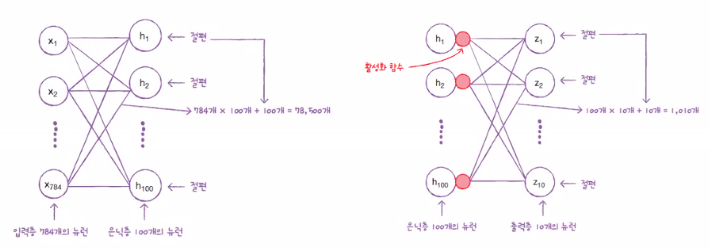

---
## 층을 추가하는 다른 방법

1. Sequential 클래스의 생성자에 레이어 객체들을 바로 전달해서 모델 객체를 한 번에 생성하는 방법

In [7]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name='은닉층'), # summary() 결과에 name도 보입니다.
    keras.layers.Dense(10, activation='softmax', name='출력층')
], name='패션 MNIST 모델')

In [8]:
model.summary()

Model: "패션 MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 은닉층 (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 출력층 (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

---
2. 많은 층을 추가하고자 할 때는 모델의 add( ) 메서드를 이용합니다.

In [9]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(100, activation='sigmoid'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 모델이 학습할 때 필요한 손실 함수, 최적화 알고리즘, 평가 지표 등을 설정하는 과정입니다.
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# epochs=5 는 48,000개의 데이터를 batch 단위로 묶어서 5번 반복 사용하며 학습한다는 뜻입니다.
# batch_size를 따로 지정하지 않으면 케라스는 기본적으로 32를 사용합니다.
model.fit(train_scaled, train_target, epochs=5)
# 전체 훈련 데이터 : 60,000, 감증 데이터 : 20% -> 12,000, 실제 학습 데이터 : 48,000

# 48,000 / 32(배치 사이즈) = 1500
# 1500/1500 : 한 epoch에서 총 1500개의 batch(미니배치)를 처리했다라는 의미입니다.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step - accuracy: 0.8064 - loss: 0.5710
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.8502 - loss: 0.4133
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.8620 - loss: 0.3769
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - accuracy: 0.8713 - loss: 0.3531
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8781 - loss: 0.3352


---
### 렐루(ReLU) 함수의 특징 및 장점

- 기존 시그모이드 함수의 한계
    - 시그모이드 함수는 초창기 신경망의 은닉층 활성화 함수로 많이 사용되었습니다.
    - 하지만 입력값이 너무 크거나 매우 작아지면, 미분값(기울기)이 0에 가까워지는 문제가 발생합니다.
        - 시그모이드 함수는 모든 입력값을 0과 1 사이의 완만한 'S'자 곡선입니다.
        - 중앙 부분($z = 0$ 부근) : 그래프가 가파르기 때문에 기울기 값이 가장 큽니다.
        - 양 끝 부분 (값이 매우 크거나 작을 때) : 그래프가 거의 평평해집니다. 즉, 기울기가 0에 수렴합니다.

    - 이로 인해 양쪽 층에서 전달된 기울기가 뒤쪽 층으로 갈수록 계속 작아지며, 결국 거의 0이 되어 학습이 쩨대로 이루어지지 않습니다.
    - 이러한 현상을 기울기 소실(Vanishing Gradient) 문제라고 합니다.
    - 특히 층이 많은 심층 신경망(Deep Neural Network) 일수록 이 문제가 누적되어 학습이 더욱 어려워집니다.

- 렐루(ReLU) 함수의 개선점

    - 동작 방식 : 입력이 양수일 경우 마치 활성화 함수가 없는 것처럼 입력을 그대로 통과시키고, 음수일 경우에도 0으로 만듭니다. ReLU는 양수 구간에서 기울기가 1로 유지됩니다.  
    기울기가 깊은 층까지 잘 전달되어 심층 신경망에서도 학습이 안정적입니다.

    - 수식 : $z > 0$ 이면 $z$를 출력하고, $z <= 0$ 이면 0을 출력합니다.

    - $f(z) = max(0, z)$

    - 현재 대부분의 딥러닝 모델에서 은닉층의 기본 활성화 함수로 사용됩니다.

    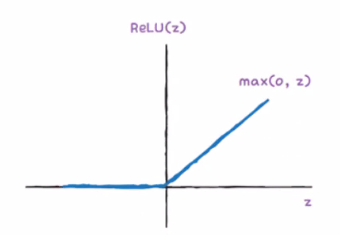

In [13]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28))) # 입력층의 형태를 (28, 28)로 변경
model.add(keras.layers.Flatten()) # 데이터를 1차원으로 만듦
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층의 뉴런 개수는 클래스의 개수와 일치해야 합니다.
# Flatten 층은 2차원 데이터를 1차원으로 변환하는 역할을 합니다.

In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [16]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 724us/step - accuracy: 0.8113 - loss: 0.5291
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.8581 - loss: 0.3915
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step - accuracy: 0.8729 - loss: 0.3529
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - accuracy: 0.8817 - loss: 0.3288
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - accuracy: 0.8878 - loss: 0.3131


In [17]:
model.evaluate(val_scaled, val_target) # 검증 데이터로 모델의 성능을 평가합니다.

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - accuracy: 0.8662 - loss: 0.3863


[0.38631802797317505, 0.8661666512489319]

---
# 옵티마이저 (Optimizer)

옵티마이저(최적화 알고리즘)는 손실 함수의 기울기(Gradient)를 이용해 가중치와 편향을 어떤 규칙으로, 얼마나 바꿀지를 결정합니다.

즉, "손실이 줄어드는 방향은 어디인가?", "한 번에 얼마나 이동할 것인가?" 를 정하는 학습의 핵심 규칙입니다.

---

### 학습 프로세스와 옵티 마이저의 역할

인공지능의 학습 단계 중 가중치를 실제로 수정하는 단계를 담당합니다.

입력 $\rightarrow$ 예측 $\rightarrow$ 손실 계산 $\rightarrow$ 기울기 계산 $\rightarrow$ 가중치 업데이트 $\leftarrow$ Optimizer가 담당

---

### 가중치 업데이트 수식

옵티마이저는 기울기($\frac{\partial Loss}{\partial w}$)를 받아서 아래와 같은 업데이트를 수행합니다.

$$w \leftarrow w - \eta \cdot \nabla J(w)$$

- $w$ : 가중치(Weight)
- $\eta$(에타) : 학습률(Learning Rate)
- $\nabla J(w)$ : 손실 함수의 기울기 (Gradient)

---

### 옵티마이저의 주요 질문

- 방향 : 어느 쪽으로 가야 손실($Loss$)이 가장 빠르게 줄어드는가?

- 보폭 : 학습률($\eta$)을 얼마나 크게 설정하여 이동할 것인가?

---

다양한 optimizer

optimizer | 특징 | 핵심 전략 | 학습 결과
--- | --- | --- | ---
SGD | 가장 기본적이면 계산이 단순함 | 경사 따라가기 | 속도가 느리고 구불구불하게 이동
SGD + momentum | 관성을 이용해 가던 방향으로 가속 | 가속도 붙이기 | 진동이 줄어 들고 직선적으로 빠르게 수렴
RMSprop | 기울기에 따라 학습률을 유동적으로 조절 | 보폭 조절하기 | 가파른 곳에선 조심하고 완만한 곳에서는 속도를 냄
Adam | 자동으로 학습률 조절, 가장 많이 사용 | 가속도 + 보폭 조절 | 가장 빠ㅡㄹ고 안정적으로 최적점에 도달함

---
옵티마이저 설정 방법

1. optimizer = 'sgd' 지정

In [18]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

위와 동일한 코드

In [19]:
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

---
SGD 클래스의 학습률 기본값은 0.01 입니다. 이를 수정하는 방법입니다.

In [20]:
sgd = keras.optimizers.SGD(learning_rate=0.1)
# SGD 옵티마이저의 학습률을 0.1로 설정하여 모델을 컴파일합니다.

---
기본 SGD에 모멘텀(가속)을 줄어 속도를 높이고 네스테로프(예측)를 더해 정확도를 높이는 방법

In [21]:
sgd = keras.optimizers.SGD(
    momentum=0.9,           # [관성] 이전 이동 거리의 90%를 다음 이동에 반영합니다.
                            # 내리막길엣 가속도를 붙여 수렴 속도를 높이고,
                            # 작은 웅덩이(Local minimum)를 관성으로 돌파하게 도와줍니다.

    nesterov=True           # [네스테로프 가속 경사] 관성에 의해 이동할 '미래 위치' 의
                            # 기울기를 미리 확인하여 업데이트합니다.
                            # 관성 때문에 목표지점을 휙 지나쳐버리는(Overshooting) 현상을
                            # 방지하여 기본 모멘텀보다 훨씬 안정적으로 멈추게 합니다.
)

---
아다그라드의 핵심 전략은 맞춤형 보폭 조절입니다.

학습률(Learning Rate)을 모든 매개변수에 똑같이 적용하지 말고, 각자 상황에 맞춰서 다르게 조절합니다.

별도의 설정이 없으면 기본 학습률(0.01)에서 시작하여 학습이 진행될수록 스스로 줄여나갑니다.

In [22]:
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

---
Adgrad는 과거의 모든 기울기를 다 더해서 보폭을 줄였기 때문에, 학습이 길어지면 보폭이 너무 작아져서 결국 학습이 멈춰버리는(0이 되는) 문제가 있었습니다.

RMSprop은 너무 먼 과거의 기울기는 잊어버리고, 최근의 기울기 변화 위주로 보폭을 조절합니다.

- 케라스의 기본 옵티마이저가 RMSprop 입니다

In [23]:
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

optimizer = 'adam'를 이용한 모델 생성

In [24]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

In [25]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Adam 옵티마이저는 학습률을 자동으로 조정하는 기능이 있어, 일반적으로 별도의 학습률 설정 없이도 좋은 성능을 낼 수 있습니다.

model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step - accuracy: 0.8154 - loss: 0.5262
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8576 - loss: 0.3955
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.8723 - loss: 0.3513
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - accuracy: 0.8829 - loss: 0.3230
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8905 - loss: 0.3017


In [26]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8751 - loss: 0.3442


[0.34416502714157104, 0.875083327293396]

- 컴퓨터에서 난수
    1. 수학 공식으로 계산되어 시작점(seed)이 같으면 결과도 100% 같습니다.
    
    2. 라이브러리마다 사용하는 난수 생성 공식이 다르기 때문에 같은 seed라도 결과는 다릅니다.
    - Python, Java, Pytorch, TensorFlow 등 각자 다른 난수 생성기(Random Number Generator, RNG) 사용합니다.
    - 같은 라이브러리 안에서는 seed 만 같으면 항상 재현이 가능합니다.

    3. 파이토치는 CPU용 난수 생성기와 GPU용 난수 생성기를 따로 관리합니다.    

    구분 | 의미 | seed 설정
    --- | --- | ---
    CPU 난수 | CPU에서 동작하는 RNG 가 만든 값 | torch.manual_seed()
    GPU 난수 | GPU(CUDA)에서 동작하는 RNG가 만든 값 | torch.cuda.manual_seed()


- 
- 결정론 (Deterministic)과 비결정론(Non-deterministic)
    - 결정론(Deterministic)과 비결정론(Non-deterministic)은 같은 입력에 대해 계산 과정과 결과가 어떻게 나타나는가를 설명하는 개념입니다.

    1. 결정론 (Deterministic)
        - 같은 입력이 주어지면 계산 과정이 항상 돌일하게 진행되며, 그 결과도 언제나 같습니다.

        - 실행 시점이나 환경이 달라져도 결과가 변하지 않기 때문에 예측 가능하며, 실험의 재현성과 디버깅에 유리합니다.

        - 같은 입력 $\rightarrow$ 같은 계산 과정 $\rightarrow$ 항상 같은 결과

    2. 비결정론(Non-deterministic)

        - 같은 입력이 주어지더라도 실행할 때마다 계산 과정이나 결과가 달라질 수 있습니다.

        - 주로 병렬 처리 환경에서 발생하며, 연산 순서가 실행마다 달라질 수 있기 때문입니다.

    - 예를 들어 CuDNN(엔비디아 딥러닝 라이브러리) 에서는 수학적으로 동일한 합성공 연산이라도 여러 내부 구현 알고리즘이 존재하며,  
    GPUY 구조와 입력 조건에 따라 가장 빠른 계산 방법이 선택됩니다. 이로 인해 실행마다 다른 알고리즘이 사용될 수 있고,  
    그 결과 비결정론적 특성이 나타날 수 있습니다.

    - 딥러닝은 GPU 병렬 연산 등으로 인해 실행할 때마다 결과가 조금씩 달라질 수 있습니다.  
    따라서 실험 결과는 한 번의 실행 결과가 아니라 여러 번 실행한 뒤 평균과 표준편차를 이용해 분석합니다.

In [27]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# 실행마다 동일한 겨로가를 얻기 위해 파이토치에 랜덤 시드를 지정하고 GPU 연산을 결정적으로 만듭니다.
import torch

torch.manual_seed(42) # CPU에서 발생하는 난수(랜덤 값)를 42번 시드로 고정합니다.

# CUDA(쿠다)는 CUDA(Compute Unified Device Architecture)는 그래픽 카드 제조사인 NVIDIA(엔비디아) 가 만든 병렬 컴퓨팅 플랫폼입니다.
if torch.cuda.is_available():                   # 현재 컴퓨터에 NVIDIA GPU가 있는지, 그리고 CUDA 드라이버가 잘 설치되어 있는지 확인합니다.
    torch.cuda.manual_seed(42)                  # GPU(CUDA) 내부에서 사용하는 난수도 42번으로 고정합니다.
    torch.backends.cudnn.deterministic = True   # cuDNN은 CUDA를 딥러닝에 최적화한 라이브러리입니다.
                                                # 기본적으로 cuDNN은 가장 빠른 계산 경로를 찾기 위해 내부 알고리즘을 매번 조금씩 바꾸는데,
                                                # 옵션을 True로 하면 무조건 똑같은 경로로 계산하게 하여 결과 오차를 없앱니다.

In [29]:
import torch # Pytorch 핵심 라이브러리

# torchvision : 이미지 처리와 컴퓨터 비전 작업을 위한 Pytorch 부속 라이브러리입니다.
# datasets : 다양한 공개 데이터셋을 쉽게 다운로드하고 사용할 수 있도록 제공하는 모듈입니다.
# FashionMNIST : 의류 이미지 데이터셋을 불러오기 위한 클래스입니다.
from torchvision.datasets import FashionMNIST

In [30]:
# root='./data_torch : 다운로드 위치 (현재 디렉터리 기준 ./data_torch/FashionMNIST/ 폴더에 저장됨)
# train=True : 훈련용 데이터셋을 불러옵니다.
# download=True : 원격에 저장된 데이터를 다운로드하여 로컬에 저장, 이미 로컬에 데이터가 있으면 다시 다운로드 하지 않습니다.
fm_train = FashionMNIST(root='./data_torch', train=True, download=True)

# train=False : 테스트 ㅔ이터 (10,000장)을 불러옵니다.
fm_test = FashionMNIST(root='./data_torch', train=False, download=True)

100.0%
100.0%
100.0%
100.0%


In [31]:
# fm_train은 FashionMNIST Dataset 객체이고 그 안의 data는 이미지 데이터 자체만 담고 있습니다.
# fm_train.data는 이미지 픽셀 값들의 모음입니다.
# torch.Tensor는 PyTorch의 Tensor 객체라는 의미입니다.
type(fm_train.data)

torch.Tensor

In [32]:
print(fm_train.data.shape, fm_test.data.shape)
# torch.Size([60000, 28, 28]) : 6만개 학습용 이미지 개수 / 28 : 이미지 높이 / 28 : 이미지 너비
# torch.Size([10000, 28, 28]) : 1만개 테스트 이미지 개수 / 28 : 이미지 높이 / 28 : 이미지 너비

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


In [33]:
print(fm_train.targets.shape, fm_test.targets.shape)
# 타겟이 1차원 이므로 원-핫 인코딩이 아니라 정숫값이라는 것을 알 수 있습니다.

torch.Size([60000]) torch.Size([10000])


In [34]:
train_input = fm_train.data # 학습용 이미지 데이터 (60000, 28, 28)
train_target = fm_train.targets # 학습용 타겟 데이터 (60000,)

In [35]:
# 정규화
train_scaled = train_input / 255.0 # 0 ~ 255 범위의 픽셀 값을 0 ~ 1 범위로 변환하여 모델이 더 빠르게 학습할 수 있도록 합니다.
# 왜 255인가? : 픽셀 값은 0에서 255 사이의 정수로 표현됩니다. 255는 8비트 이미지에서 가능한 최대 픽셀 값입니다. 
# 따라서 255로 나누면 모든 픽셀 값이 0과 1 사이의 실수로 변환되어 모델이 더 안정적으로 학습할 수 있습니다.

In [36]:
from sklearn.model_selection import train_test_split

# 훈련 세트를 다시 훈련 세트와 검증 세트로 나눕니다.
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [37]:
# train_scaled 는 6만개의 80% -> 48000개
# val_scaled 는 6만개의 20% -> 12000개
print(train_scaled.shape, val_scaled.shape)

torch.Size([48000, 28, 28]) torch.Size([12000, 28, 28])


In [38]:
import torch.nn as nn

# 784개의 입력과 100개의 뉴런을 가진 은닉층, 10개의 뉴런을 갖는 출력층을 구성해 봅시다.

# 파이토치는 모델의 입력 크기를 가전에 지정할 필요가 없습니다.

# 케라스의 Dense층과 동일한 역할을 하는 것이 파이토치의 Linear() 입니다.
# Linear(입력크기, 출력 크기-뉴런 개수)를 사용합니다.

# ReLU() : 활성화 함수를 별도의 층으로 추가해야합니다.
# 출력층 다음에 호라성화 함수가 없습니다.
model = nn.Sequential(
    nn.Flatten(),               # 2차원 이미지(28 * 28)를 1차원(784)으로 길게 펼쳐주는 역할을 합니다.
    nn.Linear(784, 100),        # 784개의 입력을 받아 100개의 뉴런으로 연결합니다. Linear(입력크기, 출력 크기-뉴런 개수)를 사용합니다.
    nn.ReLU(),                  # 활성화 함수입니다.
    nn.Linear(100, 10)          # 최종 10개 클래스(티셔츠, 바지 등)로 분류하는 출력층입니다.
)

In [39]:
# torchinfo 패키지를 설치해서 케라스의 summary() 와 비슷한 결과를 얻을 수 있습니다.
%pip install torchinfo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
from torchinfo import summary

In [41]:
# 32는 배치 사이즈를 의미합니다.
summary(model, input_size=(32, 28, 28))
# 78,500 = 가중치(Weight) + 편향(bias) = 784 * 100 + 100
#  1,010 = 가중치 (Weight) + 편향(bias) = 100 * 10 + 10

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Flatten: 1-1                           [32, 784]                 --
├─Linear: 1-2                            [32, 100]                 78,500
├─ReLU: 1-3                              [32, 100]                 --
├─Linear: 1-4                            [32, 10]                  1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.54
Input size (MB): 0.10
Forward/backward pass size (MB): 0.03
Params size (MB): 0.32
Estimated Total Size (MB): 0.45

Param # (78,500 / 1,010) : 모델이 학습해야 할 가중치(Weight)와 편향(Bias)의 개수입니다.

Total mult-adds (2.54 MB) : 데이터를 처리할 때 발생하는 곱셈과 덧셈 연산량입니다.

Input Size (0.10 MB) : 들어오는 데이터 (이미지 32장)의 크기입니다.

Params Size (0.32 MB) : 모델의 가중치들(79,510개)이 차지하는 용량입니다.

Estimated Total Size(0.45 MB) : 입력 데이터, 중간 활성값(activation), 그리고 모델의 파라미터가 차지하는 메모리를 합한 전체 메모리 사용량의 추정값입니다.

In [42]:
# 케라스의 경우 GPU가 감지 되면 자동으로 모델을 GPU에서 훈련합니다.
# 반면 PyTorch는 모델과 데이터를 명시적으로 GPU로 이동해야 합니다.
# torch.cuba.is_available() 함수는 CUDA를 사용할 수 있는 GPU가 있는지 확인합니다.
# NVIDIA GPU와 CUDA 드라이버가 정상적으로 설치되어 있으면 True를 반환하고,
# 그렇지 않으면 False를 반환합니다.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=10, bias=True)
)

In [43]:
# 손실 함수와 옵티마이저
import torch.optim as optim

# CrossEntropyLoss는 소프트맥스 함수 계산과 크로스 엔트로피 계산을 하나의 연산으로 합쳐 효율적으로 계산할 수 있도록 설게되어 있습니다.
# 다중 분류 문제를 다룰 때 파이토치 모델의 마지막에 소프트맥스 함수를 추가할 필요가 없습니다.
criterion = nn.CrossEntropyLoss() # 손실 함수로 크로스 엔트로피를 사용합니다.

# model.parameters() : 학습 대상인 모든 가중치 + bias
optimizer = optim.Adam(model.parameters()) # Adam 옵티마이저를 사용하여 모델의 가중치를 업데이트하는 방법을 정의합니다.

In [44]:
for params in model.parameters():
    print(params.shape)

# torch.Size([100, 784]) : 첫 번째 : Linear 층의 가중치로 100은 은닉층 뉴런의 개수
# torch.Size([100])      : 첫 번째 Linear 층의 절편, 100은 은닉층 뉴런 100개 각각의 bias
# torch.Size([10, 100])  : 두 번쨰 Linear 층의 가중치로 10은 출력층 뉴런의 개수
# torch.Size([10])       : 두 번째 Linear 층의 절편

torch.Size([100, 784])
torch.Size([100])
torch.Size([10, 100])
torch.Size([10])


In [45]:
print(len(train_scaled)) # 48000
print(len(train_scaled)/32) # 1500 : 48,000개의 데이터를 배치 사이즈 32로 나누면 총 1500개의 배치가 만들어집니다.

48000
1500.0


In [46]:
# 총 학습 반복 횟수(Epoch)
epochs = 5

# 전체 훈련 데이터를 배치 크기(32)를 나누어 몇 번 반복할지 계산
batches = int(len(train_scaled)/32) # 1500

for epoch in range(epochs):

    model.train()     # 모댈을 학습 모드로 설정

    train_loss = 0    # 한 에포크 동안 누적할 손실값 초기화

    # 미니배치 단위로 학습
    for i in range(batches):

        # 현재 배치에 해당하는 입력 데이터를 가져옴
        # GPU를 사용할 경우 device(GPU)로 이동
        inputs = train_scaled[i * 32 : (i + 1) * 32].to(device)

        # 현재 배치에 해당하는 정답(label) 데이터를 가져옴
        targets = train_target[i * 32 : (i + 1) * 32].to(device)

        # 이전 배치에서 계산된 Gradient를 초기화
        # PyTorch는 gradient를 누적(accmulate)하기 때문에 매 배치마다 0으로 초기화해야 함
        optimizer.zero_grad()

        # 순전파 (Forward Propagation)
        # 입력 데이터를 모델에 넣어 예측값(outputs)을 계산
        outputs = model(inputs)

        # 예측값(outputs)과 실제값(targets)을 비교하여 손실(loss)를 계산
        loss = criterion(outputs, targets)

        # 역전파(Backpropagation)
        # 손실을 기준으로 각 가중치에 대한 gradient 계산
        loss.backward()

        # 옵티마이저가 gradient를 이용해 가중치를 업데이트
        optimizer.step()

        # 현재 배치의 손실 값을 누적
        # loss.item()은 tensor 값을 Python 숫자로 변환
        train_loss += loss.item()

    # 한 에포크 동안의 평균 손실 출력
    print(f"에포크 : {epoch + 1}, 손실 : {train_loss / batches:.4f}")

에포크 : 1, 손실 : 0.5428
에포크 : 2, 손실 : 0.4004
에포크 : 3, 손실 : 0.3594
에포크 : 4, 손실 : 0.3320
에포크 : 5, 손실 : 0.3119


In [47]:
import torch

# 원소가 1개인 텐서를 생성
loss = torch.tensor(0.1234)
print(type(loss))

# 텐서에서 준수한 파이썬 숫자(float)만 추출
value = loss.item()

print(value)        # 출력 ㅣ 0.1234
print(type(value))  # 출력 ㅣ <class 'float'>

<class 'torch.Tensor'>
0.1234000027179718
<class 'float'>


In [48]:
# 여러 개의 값이 담긴 텐서 (예 : 모델의 예측값들)
predicts = torch.tensor([3, 0, 9])

# 파이썬 리스트로 변환
pred_list = predicts.tolist()

print(pred_list)        # 출력 : [3, 0, 9]
print(type(pred_list))  # 출력 : <class 'list'>

[3, 0, 9]
<class 'list'>


---
정확도를 계산하기 위한 평가 단계

In [49]:
# 모델을 평가 모드로 편환합니다.
model.eval()

# PyTorch는 기본적으로 역전파를 위해 모든 연산 과정을 기록하지만
# 평가 단계에서는 가중치를 수정하지 않으므로 이 기록 과정이 불필요합니다.
# torch.no_grad()를 사용하면 중간 연산값 저장에 필요한 메모리를 절약할 수 있습니다.
with torch.no_grad():
    # 검증 데이터를 모델이 있는 장치(cpu 또는 gpu)로 이동합니다.
    val_scaled = val_scaled.to(device)

    # 정답(label) 데이터도 같은 장치(cpu 또는 gpu)로 이동합니다.
    val_target = val_target.to(device)

    # 모델에 입력 데이터를 넣어 예측 결과를 계산합니다. (순전파 수행)
    # outputs의 형태는 (batch_size, 10) 즉 각 샘플에 대해 10개 클래스의 점수(logits)
    outputs = model(val_scaled)

    # outputs의 형태는 (데이터 개수, 클래스 개수) 입니다.
    # 예 : (10000, 10) -> 10000개 데이터, 각 데이터마다 10개 클래스 점수
    # argmax는 가장 큰 값의 인덱스를 반환합니다.
    # dim=1 은 "클래스 축"에서 가장 큰 값을 선택하라는 의미입니다.
    predicts = torch.argmax(outputs, 1)

    # 예측값(predicts)과 실제 정답(val_target)이 같은지 비교합니다.
    # True는 1, False는 0으로 계산됩니다.
    # sum()으로 맞은 개수를 구합니다.
    # item()은 tensor 값을 Python 숫자로 변환합니다.
    correct = (predicts == val_target).sum().item()

    print(correct)

# 정확도 = 맞은 개수 / 전체 데이터 개수
accuracy = correct / len(val_target)

# 소수점 4자리까지 출력
print(f"검증 정확도 : {accuracy:.4f}")



10463
검증 정확도 : 0.8719
